In [5]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [158]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train size: (209, 165)  Test size: (70, 165)
Train class counts:
 cluster
1    102
0     91
2     16
Name: count, dtype: int64
Test class counts:
 cluster
1    34
0    31
2     5
Name: count, dtype: int64


In [160]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000,
    C=1.0,
    random_state=0
)

logit_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logit),
])

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scoring = {"acc": "accuracy", "f1w": "f1_weighted"}

cv_res = cross_validate(logit_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("CV accuracy:", cv_res["test_acc"].mean(), "+/-", cv_res["test_acc"].std())
print("CV f1_weighted:", cv_res["test_f1w"].mean(), "+/-", cv_res["test_f1w"].std())
from sklearn.metrics import confusion_matrix, classification_report

logit_pipe.fit(X_train, y_train)
y_pred = logit_pipe.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))


CV accuracy: 0.7803716608594657 +/- 0.08895176113532526
CV f1_weighted: 0.7767713582743344 +/- 0.0874865325542624
Confusion matrix:
 [[25  6  0]
 [ 8 26  0]
 [ 3  0  2]]

Report:
               precision    recall  f1-score   support

           0       0.69      0.81      0.75        31
           1       0.81      0.76      0.79        34
           2       1.00      0.40      0.57         5

    accuracy                           0.76        70
   macro avg       0.84      0.66      0.70        70
weighted avg       0.77      0.76      0.75        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

Attribution object 1: per-cluster feature means

In [161]:
cluster_means = model_df[["cluster"]].join(X).groupby("cluster").mean()
cluster_stds  = model_df[["cluster"]].join(X).groupby("cluster").std()
cluster_counts = model_df["cluster"].value_counts().sort_index()

print("\nPer-cluster means (first 10 features):\n", cluster_means.iloc[:, :10])



Per-cluster means (first 10 features):
          u10__mean  u10__std   u10__min   u10__max  u10__median  u10__q05  \
cluster                                                                     
0         1.463204  4.679777 -14.611848  21.631088     1.584177 -6.096385   
1         1.407061  4.844429 -16.235027  22.924685     1.569321 -6.530076   
2         1.458013  4.683684 -14.850274  22.026844     1.733997 -6.247502   

         u10__q95  u10__annmax_mean  u10__annmax_std  u10__annmax_min  
cluster                                                                
0        9.026230         16.574150         1.778157        13.342505  
1        9.203499         17.011209         1.747711        13.583266  
2        8.816459         16.068199         1.992556        12.681465  


# Anomalies

In [162]:
X_z = (X - X.mean()) / X.std(ddof=0)
cluster_anom = model_df[["cluster"]].join(X_z).groupby("cluster").mean()

print("\nPer-cluster standardized anomalies (first 10 features):\n", cluster_anom.iloc[:, :10])



Per-cluster standardized anomalies (first 10 features):
          u10__mean  u10__std  u10__min  u10__max  u10__median  u10__q05  \
cluster                                                                   
0         0.088038 -0.112639  0.317473 -0.241859    -0.008614  0.201310   
1        -0.090027  0.117593 -0.319369  0.231926    -0.040325 -0.190586   
2         0.071573 -0.107175  0.223928 -0.096912     0.311195  0.064757   

         u10__q95  u10__annmax_mean  u10__annmax_std  u10__annmax_min  
cluster                                                                
0       -0.054792         -0.084435        -0.005210        -0.038649  
1        0.082743          0.126483        -0.127557         0.098991  
2       -0.217543         -0.328598         0.856347        -0.416557  


# Permutation importance

In [163]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# RF does not require scaling, but does require imputation
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        random_state=0,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])

rf_pipe.fit(X_train, y_train)

perm = permutation_importance(
    rf_pipe,
    X_test, y_test,
    n_repeats=50,
    random_state=0,
    n_jobs=-1
)

imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nTop 20 permutation importances:\n", imp.head(20))



Top 20 permutation importances:
 u10__mean           0.0
mwd__std            0.0
sp__annmean_min     0.0
sp__annmean_max     0.0
tp__mean            0.0
tp__std             0.0
tp__min             0.0
tp__max             0.0
tp__median          0.0
tp__q05             0.0
tp__q95             0.0
tp__annmax_mean     0.0
tp__annmax_std      0.0
tp__annmax_min      0.0
tp__annmax_max      0.0
tp__annmean_mean    0.0
tp__annmean_std     0.0
tp__annmean_min     0.0
tp__annmean_max     0.0
sp__annmean_std     0.0
dtype: float64


In [164]:
regime_table = cluster_means.copy()
regime_table.insert(0, "n", cluster_counts)

# Optional: append anomalies with a suffix
anom_table = cluster_anom.add_suffix("_anom_z")

final_table = regime_table.join(anom_table)

print(final_table.head())
# final_table.to_csv("cluster_attribution_table.csv")


           n  u10__mean  u10__std   u10__min   u10__max  u10__median  \
cluster                                                                
0        122   1.463204  4.679777 -14.611848  21.631088     1.584177   
1        136   1.407061  4.844429 -16.235027  22.924685     1.569321   
2         21   1.458013  4.683684 -14.850274  22.026844     1.733997   

         u10__q05  u10__q95  u10__annmax_mean  u10__annmax_std  ...  \
cluster                                                         ...   
0       -6.096385  9.026230         16.574150         1.778157  ...   
1       -6.530076  9.203499         17.011209         1.747711  ...   
2       -6.247502  8.816459         16.068199         1.992556  ...   

         swh__q05_anom_z  swh__q95_anom_z  swh__annmax_mean_anom_z  \
cluster                                                              
0              -0.279280        -0.184078                -0.154758   
1               0.297091         0.173078                 0.132735   
2  

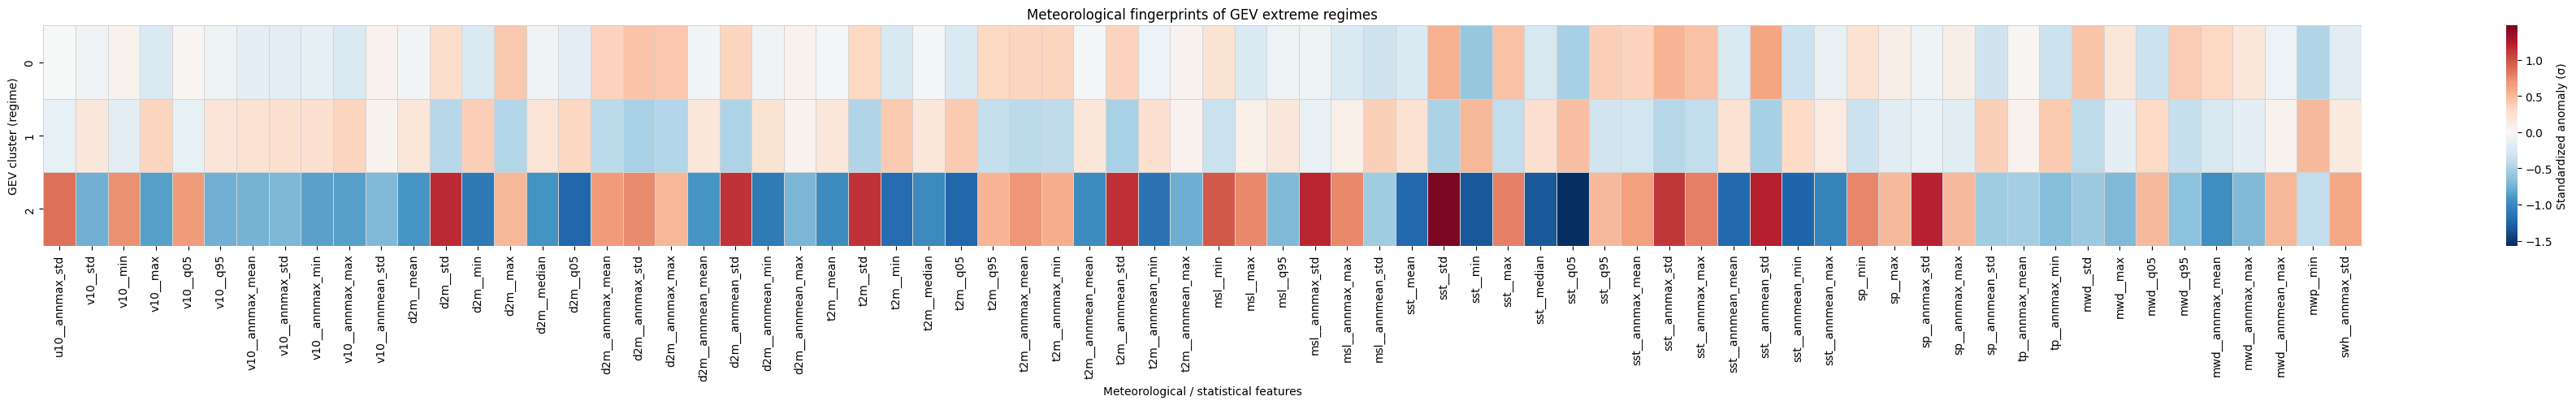

In [165]:
import pandas as pd

# Pull only anomaly columns
anom_cols = [c for c in final_table.columns if c.endswith("_anom_z")]
anom = final_table[anom_cols].copy()
anom.columns = [c.replace("_anom_z", "") for c in anom.columns]

# Optional: keep only variables that show signal
# (removes near-zero, uninformative fields)
anom = anom.loc[:, anom.abs().max(axis=0) > 0.5]
import matplotlib.pyplot as plt
import seaborn as sns  # only for plotting convenience

plt.figure(figsize=(0.45*anom.shape[1] + 4, 0.7*anom.shape[0] + 3))

sns.heatmap(
    anom,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized anomaly (σ)"}
)

plt.ylabel("GEV cluster (regime)")
plt.xlabel("Meteorological / statistical features")
plt.title("Meteorological fingerprints of GEV extreme regimes")
plt.tight_layout()
plt.show()



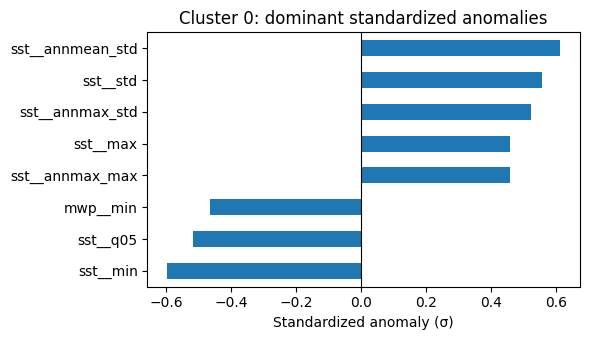

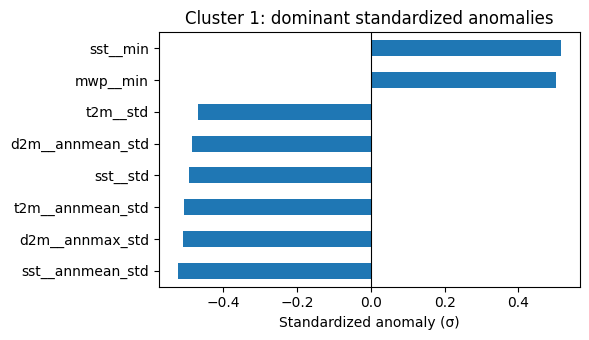

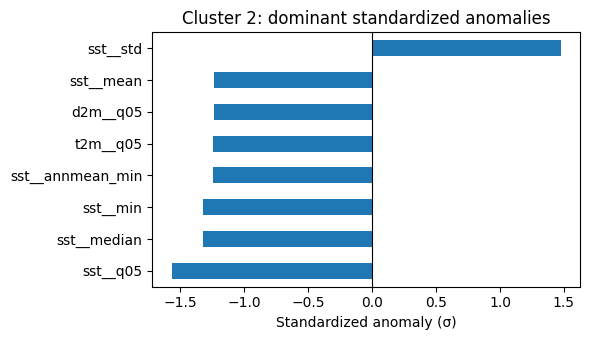

In [72]:
import numpy as np

TOP = 8  # number of variables to show per cluster

for cl in anom.index:
    s = anom.loc[cl].sort_values(key=lambda x: np.abs(x), ascending=False).head(TOP)

    plt.figure(figsize=(6, 3.5))
    s.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)

    plt.title(f"Cluster {cl}: dominant standardized anomalies")
    plt.xlabel("Standardized anomaly (σ)")
    plt.tight_layout()
    plt.show()


In [166]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs_df = pd.DataFrame(Xs, index=X.index, columns=X.columns)
Xs_df["cluster"] = model_df["cluster"].values
centroids_std = Xs_df.groupby("cluster").mean()

print("Centroids in standardized meteorological space:")
display(centroids_std.head())


Centroids in standardized meteorological space:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.088038,-0.112639,0.317473,-0.241859,-0.008614,0.201310,-0.054792,-0.084435,-0.005210,-0.038649,...,-0.279280,-0.184078,-0.154758,-0.178566,-0.110628,-0.173450,-0.211481,-0.231568,-0.233458,-0.218088
1,-0.090027,0.117593,-0.319369,0.231926,-0.040325,-0.190586,0.082743,0.126483,-0.127557,0.098991,...,0.297091,0.173078,0.132735,0.143711,0.089661,0.156348,0.209279,0.219712,0.230566,0.213357
2,0.071573,-0.107175,0.223928,-0.096912,0.311195,0.064757,-0.217543,-0.328598,0.856347,-0.416557,...,-0.150018,0.245466,0.399820,0.604346,0.364918,0.333323,0.123972,0.278763,0.143847,0.165106


In [74]:
centroids_phys = pd.DataFrame(
    scaler.inverse_transform(centroids_std),
    index=centroids_std.index,
    columns=X.columns
)

print("Centroids in physical units:")
display(centroids_phys.head())
centroid_spread = centroids_std.max(axis=0) - centroids_std.min(axis=0)
centroid_spread = centroid_spread.sort_values(ascending=False)

print("Variables defining centroid separation:")
print(centroid_spread.head(20))


Centroids in physical units:


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__q05,swh__q95,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.463204,4.679777,-14.611848,21.631088,1.584177,-6.096385,9.026230,16.574150,1.778157,13.342505,...,0.246738,2.057724,4.153114,0.530978,3.147438,5.734162,0.895297,0.061421,0.726518,1.032814
1,1.407061,4.844429,-16.235027,22.924685,1.569321,-6.530076,9.203499,17.011209,1.747711,13.583266,...,0.333686,2.337915,4.598934,0.620878,3.356475,6.503798,1.057370,0.074407,0.875422,1.224151
2,1.458013,4.683684,-14.850274,22.026844,1.733997,-6.247502,8.816459,16.068199,1.992556,12.681465,...,0.266238,2.394704,5.013106,0.749373,3.643754,6.916797,1.024511,0.076106,0.847594,1.202753


Variables defining centroid separation:
sst__q05             2.036037
sst__std             1.965970
sst__min             1.837344
sst__annmean_std     1.745010
t2m__q05             1.656688
t2m__annmean_std     1.656042
t2m__min             1.618875
d2m__annmean_std     1.613595
t2m__std             1.602838
d2m__std             1.600562
sst__median          1.592902
d2m__q05             1.574718
sst__annmax_std      1.573572
sst__annmean_min     1.568359
d2m__min             1.512420
sst__mean            1.482318
sst__annmean_mean    1.481514
t2m__annmean_min     1.420364
d2m__annmean_min     1.328913
sp__annmax_std       1.327764
dtype: float64


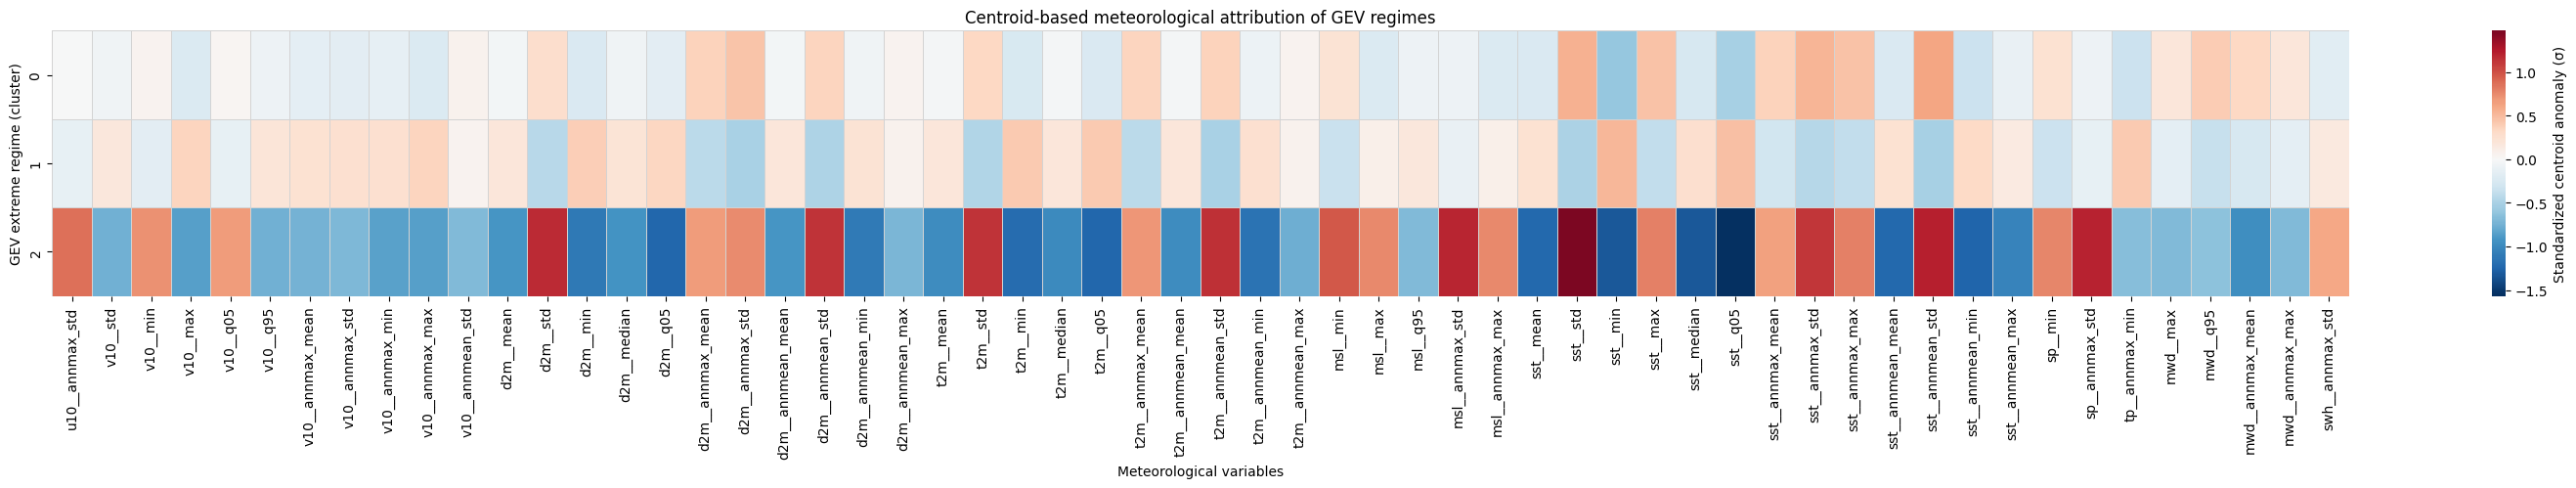

In [75]:
centroid_fingerprint = centroids_std.copy()

# Optional: drop weak signals
centroid_fingerprint = centroid_fingerprint.loc[
    :, centroid_fingerprint.abs().max() > 0.6
]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(0.45*centroid_fingerprint.shape[1] + 4,
                    0.7*centroid_fingerprint.shape[0] + 3))

sns.heatmap(
    centroid_fingerprint,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.ylabel("GEV extreme regime (cluster)")
plt.xlabel("Meteorological variables")
plt.title("Centroid-based meteorological attribution of GEV regimes")
plt.tight_layout()
plt.show()



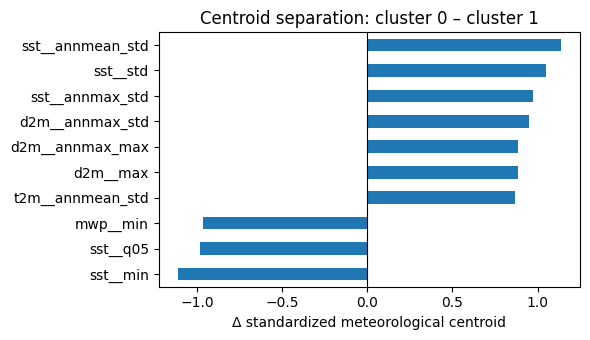

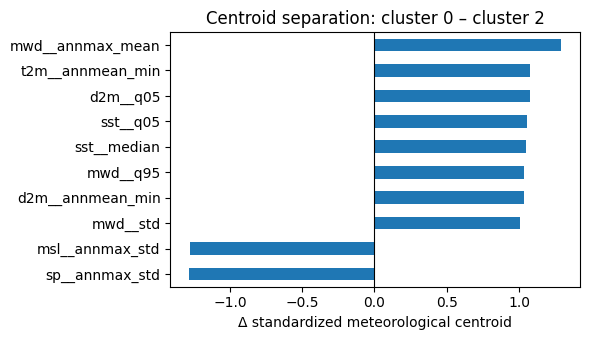

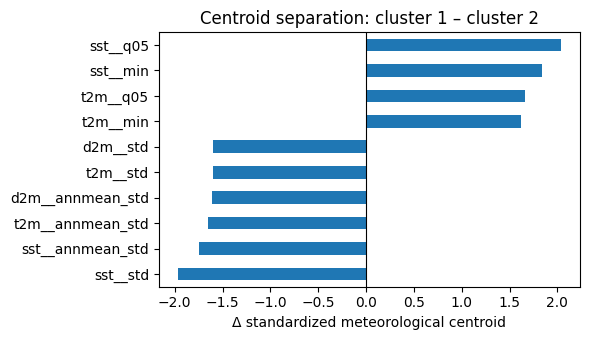

In [76]:
import itertools

for c1, c2 in itertools.combinations(centroids_std.index, 2):
    delta = (centroids_std.loc[c1] - centroids_std.loc[c2]).sort_values(
        key=lambda x: abs(x), ascending=False
    ).head(10)

    plt.figure(figsize=(6, 3.5))
    delta.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)
    plt.title(f"Centroid separation: cluster {c1} – cluster {c2}")
    plt.xlabel("Δ standardized meteorological centroid")
    plt.tight_layout()
    plt.show()


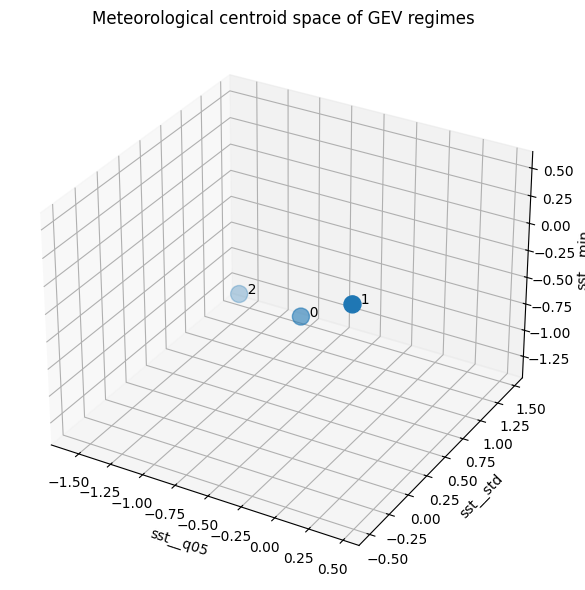

In [77]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# choose three dominant separation variables
top3 = centroid_spread.head(3).index.tolist()
C = centroids_std[top3]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[top3[0]], C[top3[1]], C[top3[2]], s=150)

for cl in C.index:
    ax.text(C.loc[cl, top3[0]],
            C.loc[cl, top3[1]],
            C.loc[cl, top3[2]],
            f"  {cl}", fontsize=10)

ax.set_xlabel(top3[0])
ax.set_ylabel(top3[1])
ax.set_zlabel(top3[2])
ax.set_title("Meteorological centroid space of GEV regimes")

plt.tight_layout()
plt.show()


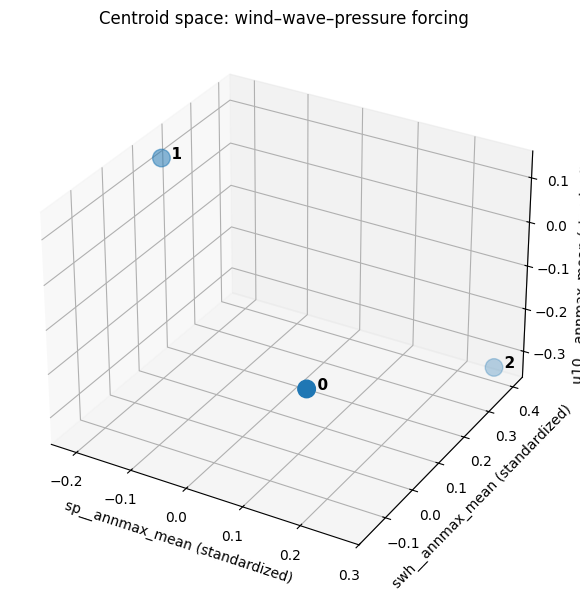

In [78]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

def plot_centroid_space(centroids, vars3, title, standardized=True):

    missing = [v for v in vars3 if v not in centroids.columns]
    if missing:
        raise ValueError(f"Missing variables: {missing}")

    C = centroids[vars3]

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(C[vars3[0]], C[vars3[1]], C[vars3[2]], s=160)

    for cl in C.index:
        ax.text(C.loc[cl, vars3[0]],
                C.loc[cl, vars3[1]],
                C.loc[cl, vars3[2]],
                f"  {cl}", fontsize=11, weight="bold")

    lab = " (standardized)" if standardized else ""
    ax.set_xlabel(vars3[0] + lab)
    ax.set_ylabel(vars3[1] + lab)
    ax.set_zlabel(vars3[2] + lab)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_centroid_space(
    centroids_std,
    ['sp__annmax_mean', 'swh__annmax_mean', 'u10__annmax_mean'],
    "Centroid space: wind–wave–pressure forcing",
    standardized=True
)


In [79]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "residual", "tide", "count", "missing")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X = model_df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in model_df.columns])
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")


# Cluster Bath stats

In [100]:
ds_sealevel = GEV_clusters

In [150]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['lat'].values
lons = ds_sealevel['lon'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
#resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
resolutions = [0.1, 0.25, 1]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

In [151]:
import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Resize a tile to (H,W) using xarray interp.
    Robust to empty / degenerate tiles and to descending coords.
    """
    # Basic dimension checks
    if ("lat" not in ds_tile.dims) or ("lon" not in ds_tile.dims):
        raise ValueError(f"Tile missing lat/lon dims: dims={ds_tile.dims}")

    nlat = ds_tile.sizes.get("lat", 0)
    nlon = ds_tile.sizes.get("lon", 0)

    # Empty tile: return a blank (NaN) tile with target coords
    if nlat == 0 or nlon == 0:
        # Try to preserve variable names; create NaN arrays for vars on (lat, lon)
        lat = np.linspace(0.0, 0.0, H, dtype=np.float32)
        lon = np.linspace(0.0, 0.0, W, dtype=np.float32)
        out = xr.Dataset(coords={"lat": lat, "lon": lon})
        for v in ds_tile.data_vars:
            if set(ds_tile[v].dims) >= {"lat", "lon"}:
                out[v] = xr.DataArray(np.full((H, W), np.nan, dtype=np.float32), dims=("lat", "lon"))
        return out

    # Degenerate tile: interp needs at least 2 points along each axis for linear
    # (if you can accept nearest, you can switch methods conditionally)
    method = "linear"
    if nlat < 2 or nlon < 2:
        method = "nearest"

    # Ensure monotonic ascending coords for interp
    ds = ds_tile.sortby(["lat", "lon"])

    lat0 = float(ds["lat"].values[0])
    lat1 = float(ds["lat"].values[-1])
    lon0 = float(ds["lon"].values[0])
    lon1 = float(ds["lon"].values[-1])

    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    return ds.interp(lat=new_lat, lon=new_lon, method=method)

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

In [152]:
import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  48.383000  -4.495000       0.314652           0.618534        2.797581   
1  45.568480  -1.061555            NaN                NaN             NaN   
2  50.102000  -5.542000       0.469762           0.892700        4.550620   
3  50.103000  -5.542750       0.716422           1.212880        5.287394   
4  50.099998  -5.533330       0.471409           0.975480        4.209303   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0       -1.354011        0.591017            2.602795         7.936331   
1             NaN             NaN                 NaN              NaN   
2       -4.932380        0.464575            2.025659         7.411496   
3       -4.070334        0.465226            2.143751         7.852673   
4       -8.839199        0.512022            2.552270        10.623257   

   mean_bathy_0.25  slope_deg_1  roughness_std_1  relief_p2p_1  mean_bathy_1  
0        -4.2

In [155]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "bath_cluster", "residual", "tide", "count", "missing", "latitude", "longitude")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X_bath = df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in df.columns])
X_bath = X_bath.apply(pd.to_numeric, errors="coerce")
X_bath = X_bath.dropna(axis=1, how="all")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X_bath)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, whiten=True)  # retain 90% variance
Xs = pca.fit_transform(Xs)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

df = df.copy()
df["bath_cluster"] = met_cluster

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77633/2610086348.py:9: RuntimeWarning: Mean of empty slice
  feature_cols[col] = df[col].apply(lambda x: np.nanmean(x))


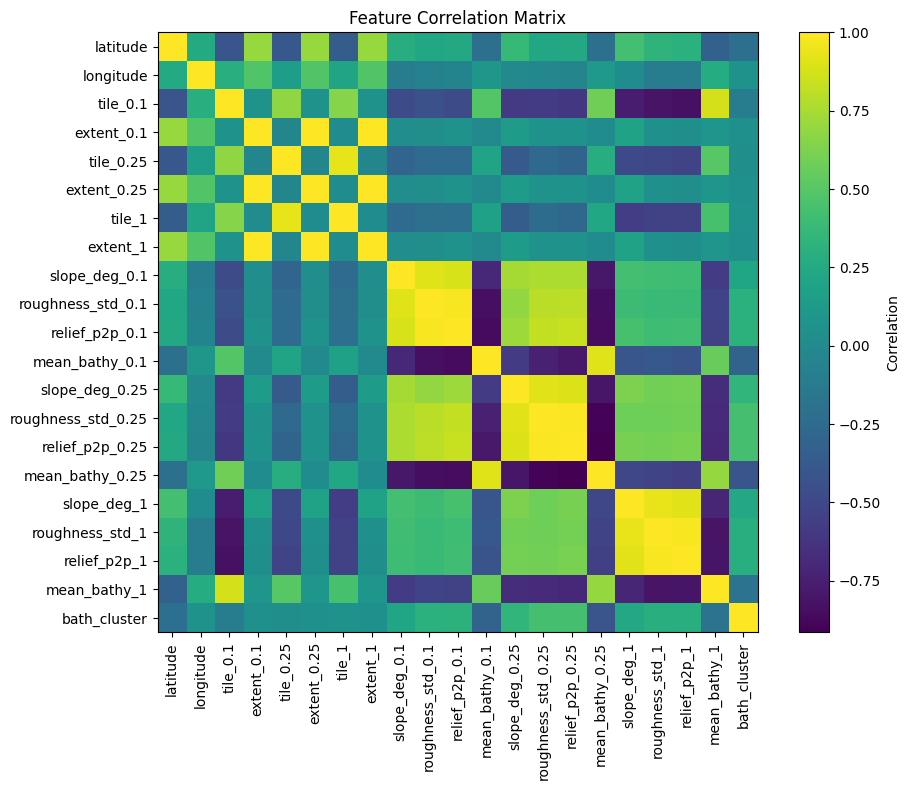

In [156]:
import numpy as np
import pandas as pd

feature_cols = {}

for col in df.columns:
    if df[col].dtype == object:
        # assume tiles (2D arrays)
        feature_cols[col] = df[col].apply(lambda x: np.nanmean(x))
    else:
        # numeric scalars like latitude / longitude
        feature_cols[col] = df[col]

feat_df = pd.DataFrame(feature_cols)
corr = feat_df.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr.values)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



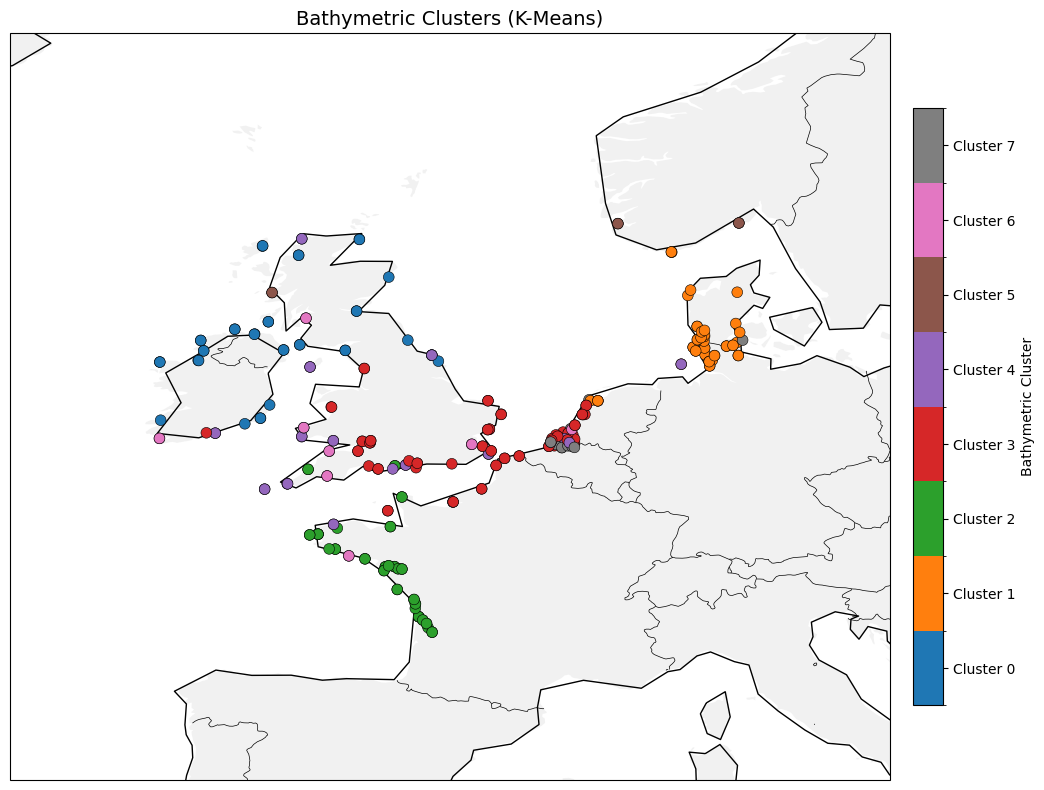

In [157]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# Prepare discrete colormap
# -----------------------------
clusters = np.sort(df["bath_cluster"].unique())
n_clusters = len(clusters)

# Use a base categorical colormap and discretize it
base_cmap = plt.get_cmap("tab10")  # good for discrete categories
colors = base_cmap(range(n_clusters))
cmap = ListedColormap(colors)

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# Create Cartopy map
# -----------------------------
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()  # or restrict extent if desired
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)

# -----------------------------
# Scatter plot of stations
# -----------------------------
sc = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["bath_cluster"],
    cmap=cmap,
    norm=norm,
    s=60,
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)

cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    shrink=0.8,
    ticks=clusters
)
cbar.set_label("Bathymetric Cluster")
cbar.set_ticks(clusters)
cbar.set_ticklabels([f"Cluster {i}" for i in clusters])

ax.set_title("Bathymetric Clusters (K-Means)", fontsize=14)
ax.set_extent([-15,15,40,65])

plt.tight_layout()
plt.show()


In [168]:
df.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/results/bath_clusters.csv")

In [170]:
bath_df = df

In [172]:
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

# -----------------------------
# 0) Inputs you have
# -----------------------------
# model_df: has ["lat","lon","cluster"] (GEV regime), optionally other cols
# bath_df:  has ["lat","lon","bath_cluster"] and bathymetry features

# Ensure consistent column names
# If bath_df uses different names, rename them here:
# bath_df = bath_df.rename(columns={"latitude":"lat","longitude":"lon","cluster":"bath_cluster"})

# -----------------------------
# 1) Nearest-neighbor merge
# -----------------------------
# Build BallTree on bath points (haversine distance)
bath_coords_rad = np.deg2rad(bath_df[["latitude","longitude"]].to_numpy())
model_coords_rad = np.deg2rad(model_df[["lat","lon"]].to_numpy())

tree = BallTree(bath_coords_rad, metric="haversine")

# Query nearest bath point for each model point
dist_rad, idx = tree.query(model_coords_rad, k=1)

# Convert to km
earth_radius_km = 6371.0
dist_km = dist_rad[:, 0] * earth_radius_km
idx = idx[:, 0]

# Set a maximum allowed match distance (choose something sensible for your station spacing)
max_match_km = 5.0  # adjust: 1–10 km typical depending on your grids/stations

matched = model_df.copy()
matched["bath_match_km"] = dist_km
matched["bath_idx"] = idx

# Attach bath_cluster + bath features from nearest neighbor
bath_cols_to_add = [c for c in bath_df.columns if c not in ["lat","lon"]]
matched = matched.join(bath_df.iloc[idx][bath_cols_to_add].reset_index(drop=True))

# Drop rows that did not match within tolerance
matched = matched[matched["bath_match_km"] <= max_match_km].copy()

print("Matched rows:", len(matched), "out of", len(model_df))
print("Max match distance (km):", matched["bath_match_km"].max())


Matched rows: 279 out of 279
Max match distance (km): 0.0


In [184]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

# -----------------------------
# 2a) Select bathymetry feature columns
# -----------------------------
exclude = {"lat","lon","bath_cluster","cluster","met_cluster","bath_match_km","bath_idx"}
bath_features = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(matched[c])]

# -----------------------------
# After selecting bath features
# -----------------------------
Xb = df[bath_features].copy()

# Drop columns with any NaNs
Xb_clean = Xb.dropna(axis=1)

print("Original bath features:", Xb.shape[1])
print("Remaining bath features:", Xb_clean.shape[1])
print("Dropped:", set(Xb.columns) - set(Xb_clean.columns))


from sklearn.preprocessing import StandardScaler

scaler_b = StandardScaler()
Zb = pd.DataFrame(
    scaler_b.fit_transform(Xb_clean),
    index=Xb_clean.index,
    columns=Xb_clean.columns
)


# -----------------------------
# 2b) Centroids and GEV means in bath space
# -----------------------------
bath_centroids = Zb.join(matched["bath_cluster"]).groupby("bath_cluster").mean()
gev_means_in_bath_space = Zb.join(matched["cluster"]).groupby("cluster").mean()

# (Optional) map each GEV regime to nearest bath centroid
dist_bath = pd.DataFrame(
    cdist(gev_means_in_bath_space.to_numpy(), bath_centroids.to_numpy(), metric="euclidean"),
    index=gev_means_in_bath_space.index,
    columns=bath_centroids.index
)
gev_to_bath_summary = pd.DataFrame({
    "closest_bath_cluster": dist_bath.idxmin(axis=1),
    "dist_to_closest_bath_centroid": dist_bath.min(axis=1)
}).sort_index()

print(gev_to_bath_summary)


Original bath features: 14
Remaining bath features: 2
Dropped: {'roughness_std_0.1', 'slope_deg_0.25', 'roughness_std_1', 'relief_p2p_0.1', 'slope_deg_1', 'mean_bathy_1', 'relief_p2p_1', 'mean_bathy_0.25', 'slope_deg_0.1', 'relief_p2p_0.25', 'mean_bathy_0.1', 'roughness_std_0.25'}
         closest_bath_cluster  dist_to_closest_bath_centroid
cluster                                                     
0                           3                       0.217051
1                           4                       0.122318
2                           1                       0.526694


In [199]:
# Ensure df and matched align on the same index (recommended)
df_aligned = df.loc[matched.index].copy()

# Quick QC
assert len(df_aligned) == len(matched)

import pandas as pd
from sklearn.preprocessing import StandardScaler

exclude = {"latitude","longitude","bath_cluster","cluster","met_cluster","bath_match_km","bath_idx"}

bath_features = [
    c for c in df_aligned.columns
    if (c not in exclude) and pd.api.types.is_numeric_dtype(df_aligned[c])
]

Xb = df_aligned[bath_features].copy()

# Drop columns with any NaNs (your preference)
Xb_clean = Xb.dropna(axis=0)

# IMPORTANT: restrict matched to the same rows
matched_clean = matched.loc[Xb_clean.index].copy()

print("Original bath features:", Xb.shape[1])
print("Remaining bath features:", Xb_clean.shape[1])
print("Dropped:", set(Xb.columns) - set(Xb_clean.columns))

# Standardize
scaler_b = StandardScaler()
Zb = pd.DataFrame(
    scaler_b.fit_transform(Xb_clean),
    index=Xb_clean.index,
    columns=Xb_clean.columns
)

# Centroids / means using matched_clean
bath_centroids = Zb.join(matched_clean["bath_cluster"]).groupby("bath_cluster").mean()
gev_means_in_bath_space = Zb.join(matched_clean["cluster"]).groupby("cluster").mean()

# Distance matrix
dist_bath = pd.DataFrame(
    cdist(gev_means_in_bath_space.to_numpy(), bath_centroids.to_numpy(), metric="euclidean"),
    index=gev_means_in_bath_space.index,
    columns=bath_centroids.index
)

gev_to_bath_summary = pd.DataFrame({
    "closest_bath_cluster": dist_bath.idxmin(axis=1),
    "dist_to_closest_bath_centroid": dist_bath.min(axis=1)
}).sort_index()

# PCA
pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Zb.to_numpy())

bath2 = pca.transform(bath_centroids[Zb.columns].to_numpy())
gev2  = pca.transform(gev_means_in_bath_space[Zb.columns].to_numpy())

# Codes MUST come from matched_clean (same index/length as Zb)
bath_labels = np.sort(matched_clean["bath_cluster"].unique())
lab2code = {lab: i for i, lab in enumerate(bath_labels)}
codes = matched_clean["bath_cluster"].map(lab2code).to_numpy()


Original bath features: 12
Remaining bath features: 12
Dropped: set()


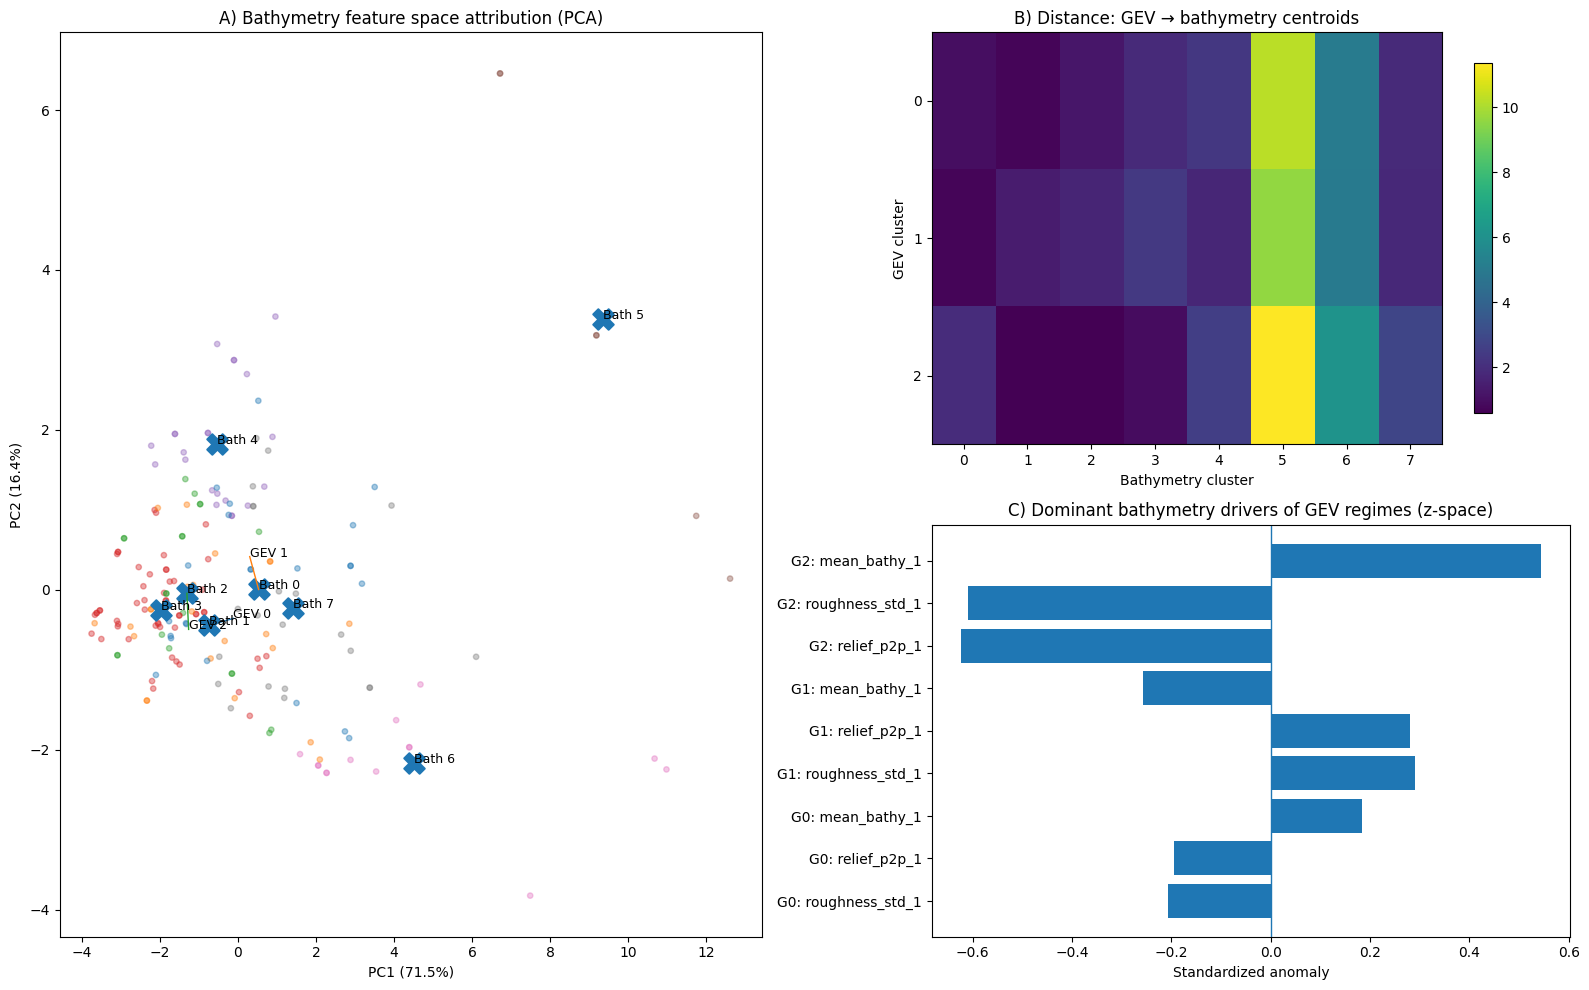

In [200]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.decomposition import PCA


base = plt.get_cmap("tab10") if len(bath_labels) <= 10 else plt.get_cmap("tab20")
cmap = ListedColormap(base(range(len(bath_labels))))
norm = BoundaryNorm(np.arange(-0.5, len(bath_labels) + 0.5, 1), cmap.N)

# Layout
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1])

# Panel A — PCA
ax0 = fig.add_subplot(gs[:, 0])
ax0.scatter(Z2[:, 0], Z2[:, 1], c=codes, cmap=cmap, norm=norm, s=15, alpha=0.4)
ax0.scatter(bath2[:, 0], bath2[:, 1], marker="X", s=220, linewidths=1.4)
ax0.scatter(gev2[:, 0], gev2[:, 1], facecolors="none", s=200, linewidths=2)

for i, b in enumerate(bath_centroids.index):
    ax0.text(bath2[i, 0], bath2[i, 1], f"Bath {b}", fontsize=9)
for i, g in enumerate(gev_means_in_bath_space.index):
    ax0.text(gev2[i, 0], gev2[i, 1], f"GEV {g}", fontsize=9)

bath_index_to_pos = {b: j for j, b in enumerate(bath_centroids.index)}
for i, g in enumerate(gev_means_in_bath_space.index):
    b = gev_to_bath_summary.loc[g, "closest_bath_cluster"]
    j = bath_index_to_pos[b]
    ax0.plot([gev2[i, 0], bath2[j, 0]], [gev2[i, 1], bath2[j, 1]], linewidth=1)

ax0.set_title("A) Bathymetry feature space attribution (PCA)")
ax0.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax0.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Panel B — Distance heatmap
ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(dist_bath.values, aspect="auto")
ax1.set_title("B) Distance: GEV → bathymetry centroids")
ax1.set_xlabel("Bathymetry cluster")
ax1.set_ylabel("GEV cluster")
ax1.set_xticks(range(len(dist_bath.columns)))
ax1.set_xticklabels(dist_bath.columns)
ax1.set_yticks(range(len(dist_bath.index)))
ax1.set_yticklabels(dist_bath.index)
plt.colorbar(im, ax=ax1, shrink=0.85)

# Panel C — Top bath drivers per GEV regime
ax2 = fig.add_subplot(gs[1, 1])
bars, labels = [], []

for g in gev_means_in_bath_space.index:
    top = gev_means_in_bath_space.loc[g].abs().sort_values(ascending=False).head(3)
    for f in top.index:
        bars.append(gev_means_in_bath_space.loc[g, f])
        labels.append(f"G{g}: {f}")

ax2.barh(labels, bars)
ax2.axvline(0, linewidth=1)
ax2.set_title("C) Dominant bathymetry drivers of GEV regimes (z-space)")
ax2.set_xlabel("Standardized anomaly")

plt.tight_layout()
plt.show()



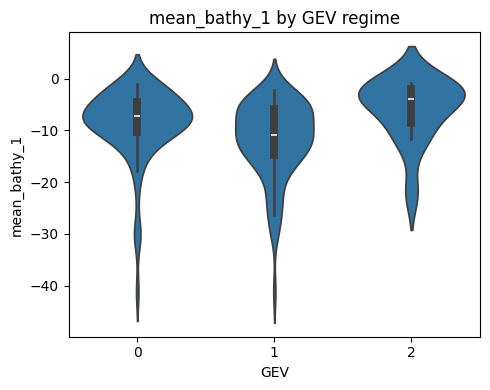

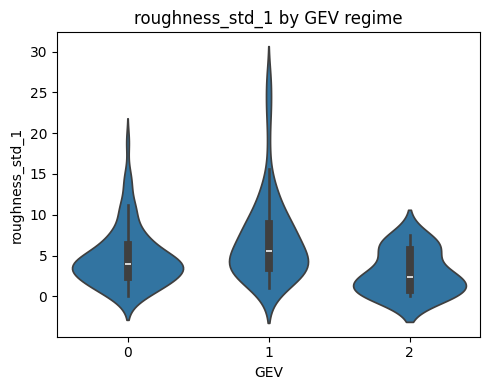

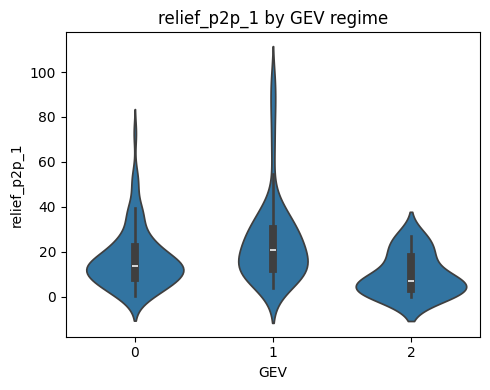

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

bath_vars = ["mean_bathy_1", "roughness_std_1", "relief_p2p_1"]  # adjust

plot_df = df_aligned.loc[Zb.index].copy()
plot_df["GEV"] = matched_clean["cluster"]

for v in bath_vars:
    plt.figure(figsize=(5,4))
    sns.violinplot(data=plot_df, x="GEV", y=v, inner="box")
    plt.title(f"{v} by GEV regime")
    plt.tight_layout()
    plt.show()


     mean_bathy_1  roughness_std_1  relief_p2p_1
GEV                                             
0        0.182468        -0.206435     -0.194832
1       -0.256428         0.289119      0.280115
2        0.542765        -0.607347     -0.622265


<Axes: xlabel='mean_bathy_1', ylabel='gev_scale'>

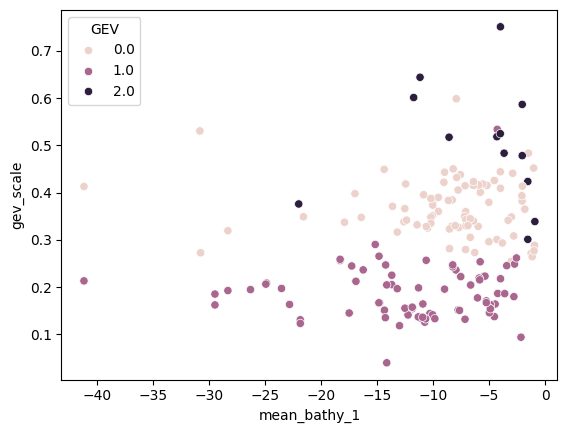

In [206]:
bath_by_gev = plot_df.groupby("GEV")[bath_vars].mean()
global_mean = plot_df[bath_vars].mean()
global_std  = plot_df[bath_vars].std()

effect = (bath_by_gev - global_mean) / global_std
print(effect)
sns.scatterplot(data=plot_df, x="mean_bathy_1", y=GEV_clusters["gev_scale"], hue=plot_df["GEV"])


In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

# -----------------------------
# 1) Select bathymetry feature columns (numeric), exclude non-features
# -----------------------------
exclude = {
    "latitude","longitude",
    "cluster",          # GEV regime
    "met_cluster",
    "bath_cluster",
    "bath_match_km",
    "bath_idx"
}

bath_features = [
    c for c in df.columns
    if (c not in exclude) and pd.api.types.is_numeric_dtype(matched[c])
]

Xb = df[bath_features].copy()

# Drop columns with any NaNs (your preference)
Xb = Xb.dropna(axis=1)

print("Bathymetry features used:", Xb.shape[1])

# -----------------------------
# 2) Standardize bathymetry feature space
# -----------------------------
scaler = StandardScaler()
Zb = pd.DataFrame(
    scaler.fit_transform(Xb),
    index=Xb.index,
    columns=Xb.columns
)

# -----------------------------
# 3) Bath centroids + GEV means in bath space
# -----------------------------
bath_centroids = Zb.join(df["bath_cluster"]).groupby("bath_cluster").mean()
gev_means_in_bath_space = Zb.join(df["cluster"]).groupby("cluster").mean()

# Distances: GEV → bath centroids
gev_mat = gev_means_in_bath_space[bath_centroids.columns].to_numpy()
bath_mat = bath_centroids.to_numpy()

dist_bath = pd.DataFrame(
    cdist(gev_mat, bath_mat, metric="euclidean"),
    index=gev_means_in_bath_space.index,   # GEV clusters
    columns=bath_centroids.index           # bath clusters
)

gev_to_bath_summary = pd.DataFrame({
    "closest_bath_cluster": dist_bath.idxmin(axis=1),
    "dist_to_closest_bath_centroid": dist_bath.min(axis=1)
}).sort_index()

# -----------------------------
# 4) PCA projection in bath space
# -----------------------------
pca = PCA(n_components=2, random_state=0)
Z2 = pca.fit_transform(Zb.to_numpy())

bath2 = pca.transform(bath_centroids[Zb.columns].to_numpy())
gev2  = pca.transform(gev_means_in_bath_space[Zb.columns].to_numpy())

# Discrete colormap for bath clusters
bath_labels = np.sort(df["bath_cluster"].unique())
lab2code = {lab: i for i, lab in enumerate(bath_labels)}
codes = df["bath_cluster"].map(lab2code)

base = plt.get_cmap("tab10") if len(bath_labels) <= 10 else plt.get_cmap("tab20")
cmap = ListedColormap(base(range(len(bath_labels))))
norm = BoundaryNorm(np.arange(-0.5, len(bath_labels) + 0.5, 1), cmap.N)

# -----------------------------
# 5) Composite figure layout (same as your meteorological one)
# -----------------------------
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1])

# -----------------------
# Panel A — PCA space (bath)
# -----------------------
ax0 = fig.add_subplot(gs[:, 0])

sc = ax0.scatter(Z2[:, 0], Z2[:, 1], c=codes, cmap=cmap, norm=norm, s=15, alpha=0.4)
ax0.scatter(bath2[:, 0], bath2[:, 1], marker="X", s=220, linewidths=1.4)
ax0.scatter(gev2[:, 0], gev2[:, 1], facecolors="none", s=200, linewidths=2)

for i, b in enumerate(bath_centroids.index):
    ax0.text(bath2[i, 0], bath2[i, 1], f"Bath {b}", fontsize=9)

for i, g in enumerate(gev_means_in_bath_space.index):
    ax0.text(gev2[i, 0], gev2[i, 1], f"GEV {g}", fontsize=9)

# lines from each GEV mean to closest bath centroid
bath_index_to_pos = {b: j for j, b in enumerate(bath_centroids.index)}
for i, g in enumerate(gev_means_in_bath_space.index):
    b = gev_to_bath_summary.loc[g, "closest_bath_cluster"]
    j = bath_index_to_pos[b]
    ax0.plot([gev2[i, 0], bath2[j, 0]], [gev2[i, 1], bath2[j, 1]], linewidth=1)

ax0.set_title("A) Bathymetry feature space attribution (PCA)")
ax0.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax0.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# -----------------------
# Panel B — distance heatmap (GEV → bath centroids)
# -----------------------
ax1 = fig.add_subplot(gs[0, 1])
im = ax1.imshow(dist_bath.values, aspect="auto")
ax1.set_title("B) Distance: GEV → bathymetry centroids")
ax1.set_xlabel("Bathymetry cluster")
ax1.set_ylabel("GEV cluster")
ax1.set_xticks(range(len(dist_bath.columns)))
ax1.set_xticklabels(dist_bath.columns)
ax1.set_yticks(range(len(dist_bath.index)))
ax1.set_yticklabels(dist_bath.index)
plt.colorbar(im, ax=ax1, shrink=0.85)

# -----------------------
# Panel C — top drivers in bath space (z-space)
# -----------------------
ax2 = fig.add_subplot(gs[1, 1])

bars = []
labels = []

for g in gev_means_in_bath_space.index:
    top = gev_means_in_bath_space.loc[g].abs().sort_values(ascending=False).head(3)
    for f in top.index:
        bars.append(gev_means_in_bath_space.loc[g, f])
        labels.append(f"G{g}: {f}")

ax2.barh(labels, bars)
ax2.axvline(0, linewidth=1)
ax2.set_title("C) Dominant bathymetry drivers of GEV regimes (z-space)")
ax2.set_xlabel("Standardized anomaly")

plt.tight_layout()
plt.show()



Bathymetry features used: 0


ValueError: at least one array or dtype is required

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X)


In [81]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

model_df = model_df.copy()
model_df["met_cluster"] = met_cluster

print(model_df["met_cluster"].value_counts())


met_cluster
8    56
2    41
6    32
4    31
7    28
1    28
0    22
3    14
5    14
9    13
Name: count, dtype: int64


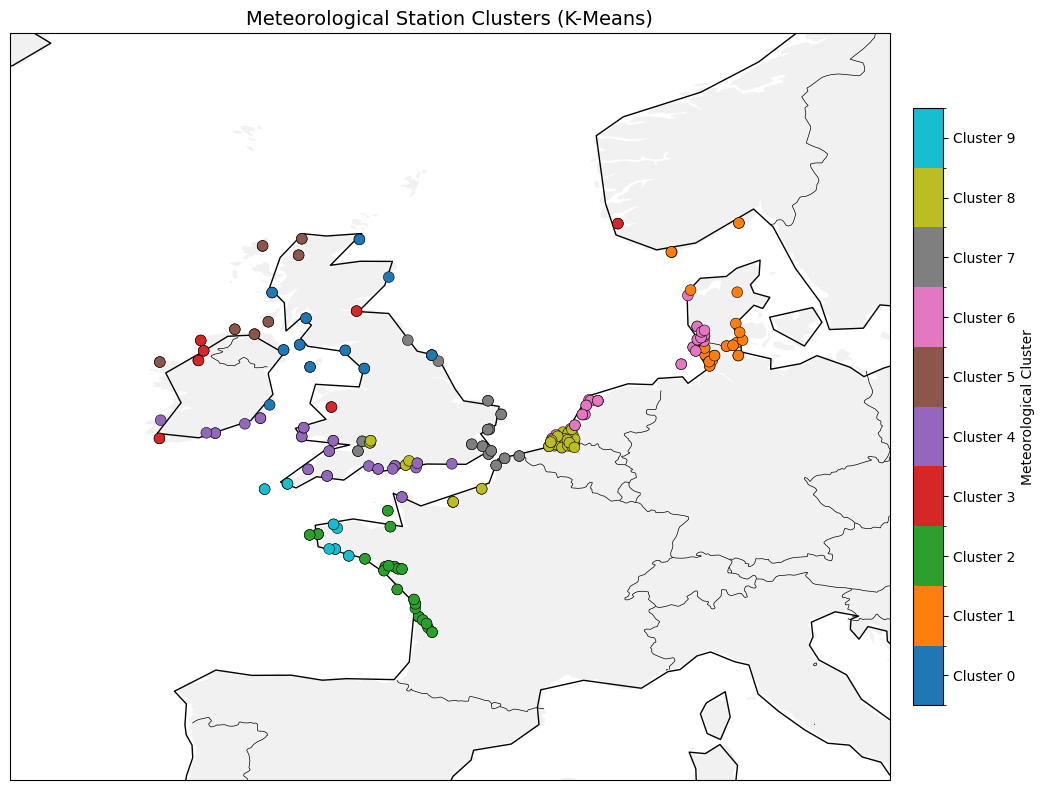

In [86]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# Prepare discrete colormap
# -----------------------------
clusters = np.sort(model_df["met_cluster"].unique())
n_clusters = len(clusters)

# Use a base categorical colormap and discretize it
base_cmap = plt.get_cmap("tab10")  # good for discrete categories
colors = base_cmap(range(n_clusters))
cmap = ListedColormap(colors)

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# Create Cartopy map
# -----------------------------
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()  # or restrict extent if desired
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)

# -----------------------------
# Scatter plot of stations
# -----------------------------
sc = ax.scatter(
    model_df["lon"],
    model_df["lat"],
    c=model_df["met_cluster"],
    cmap=cmap,
    norm=norm,
    s=60,
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# -----------------------------
# Discrete colorbar
# -----------------------------
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    shrink=0.8,
    ticks=clusters
)
cbar.set_label("Meteorological Cluster")
cbar.set_ticks(clusters)
cbar.set_ticklabels([f"Cluster {i}" for i in clusters])

ax.set_title("Meteorological Station Clusters (K-Means)", fontsize=14)
ax.set_extent([-15,15,40,65])

plt.tight_layout()
plt.show()


In [87]:
centroids_met_std = pd.DataFrame(
    km_met.cluster_centers_,
    columns=X.columns
)


In [88]:
# Recover scaler and imputer from the pipeline
imputer = met_pre.named_steps["imputer"]
scaler  = met_pre.named_steps["scaler"]

# KMeans centers are in standardized space; invert scaling
centroids_met_imputed = scaler.inverse_transform(km_met.cluster_centers_)  # imputed space
centroids_met_phys = pd.DataFrame(centroids_met_imputed, columns=X.columns)

display(centroids_met_phys.head())


,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__annmax_mean,u10__annmax_std,u10__annmax_min,...,swh__annmax_mean,swh__annmax_std,swh__annmax_min,swh__annmax_max,swh__annmean_mean,swh__annmean_std,swh__annmean_min,swh__annmean_max,lat,lon
0,1.493893,4.936673,-17.759583,22.267737,1.627704,-6.766836,9.405391,17.233136,1.805289,13.717512,...,4.358663,0.603008,3.195276,6.145064,0.878576,0.059422,0.726083,1.044762,55.184715,-3.767352
1,1.253516,4.435655,-14.537572,20.479311,1.575985,-6.129123,8.099815,14.662564,1.813666,11.615308,...,3.936022,0.529310,2.805974,5.303459,0.782348,0.052201,0.649679,0.933687,55.448316,9.106446
2,1.143746,4.853881,-15.669377,24.305782,1.087590,-6.441626,9.332333,18.093330,1.844395,14.454755,...,3.012119,0.246531,2.431465,3.703932,0.739673,0.049666,0.620675,0.864508,46.939025,-2.034317
3,1.168816,3.784060,-13.401906,19.669264,1.139278,-4.972217,7.403560,14.716230,1.670735,11.259785,...,4.601243,0.671527,3.129822,6.598688,1.036583,0.080707,0.839456,1.228106,54.752210,-5.265631
4,1.730227,5.123645,-16.983379,22.892736,2.108000,-6.926058,9.682780,17.139942,1.622060,13.857069,...,5.269758,0.789975,3.747316,7.819257,1.074165,0.076811,0.892346,1.247692,51.156093,-4.138701


In [89]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")
print(ct)


met_cluster         0         1         2         3         4         5  \
cluster                                                                   
0            0.065574  0.008197  0.065574  0.024590  0.049180  0.016393   
1            0.102941  0.110294  0.242647  0.080882  0.176471  0.088235   
2            0.000000  0.571429  0.000000  0.000000  0.047619  0.000000   

met_cluster         6         7         8         9  
cluster                                              
0            0.221311  0.172131  0.352459  0.024590  
1            0.007353  0.051471  0.066176  0.073529  
2            0.190476  0.000000  0.190476  0.000000  


In [90]:
from scipy.stats import chi2_contingency

ct_counts = pd.crosstab(model_df["cluster"], model_df["met_cluster"])
chi2, p, dof, expected = chi2_contingency(ct_counts)

print("chi2:", chi2, "p-value:", p)


chi2: 169.08709593312676 p-value: 1.370637162936017e-26


In [91]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(model_df["cluster"], model_df["met_cluster"])
print("Mutual information:", mi)


Mutual information: 0.3064172502516693


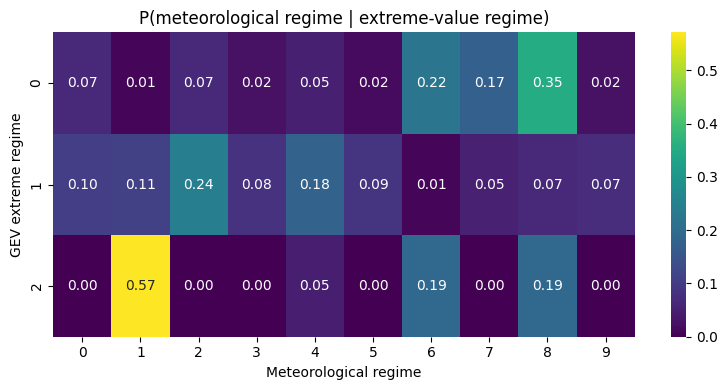

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

plt.figure(figsize=(8,4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="viridis")

plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("P(meteorological regime | extreme-value regime)")

plt.tight_layout()
plt.show()


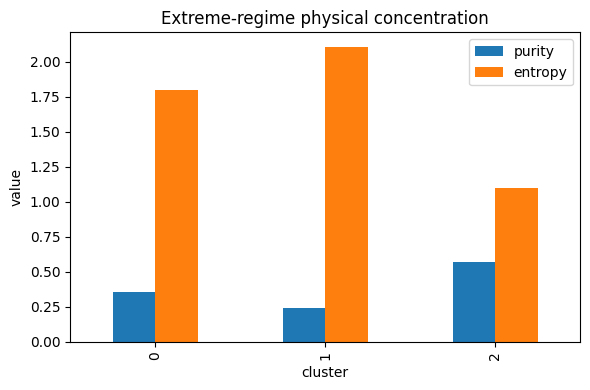

In [93]:
ct = pd.crosstab(model_df["cluster"], model_df["met_cluster"], normalize="index")

dominant = ct.idxmax(axis=1)
purity = ct.max(axis=1)
entropy = -(ct * np.log(ct + 1e-12)).sum(axis=1)

summary = pd.DataFrame({
    "dominant_met_regime": dominant,
    "purity": purity,
    "entropy": entropy
})

summary[["purity", "entropy"]].plot(kind="bar", figsize=(6,4))
plt.title("Extreme-regime physical concentration")
plt.ylabel("value")
plt.tight_layout()
plt.show()


Interpretation:

purity → how concentrated the attribution is

entropy → how many meteorological pathways exist

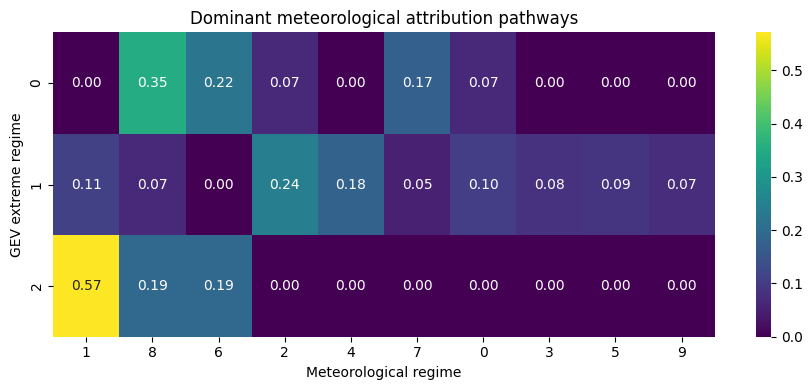

In [94]:
# order columns by overall contribution
order = ct.sum(axis=0).sort_values(ascending=False).index
ct_ord = ct[order]

# zero-out very small probabilities
ct_masked = ct_ord.where(ct_ord > 0.05, 0)

plt.figure(figsize=(9,4))
sns.heatmap(ct_masked, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("Dominant meteorological attribution pathways")
plt.tight_layout()
plt.show()


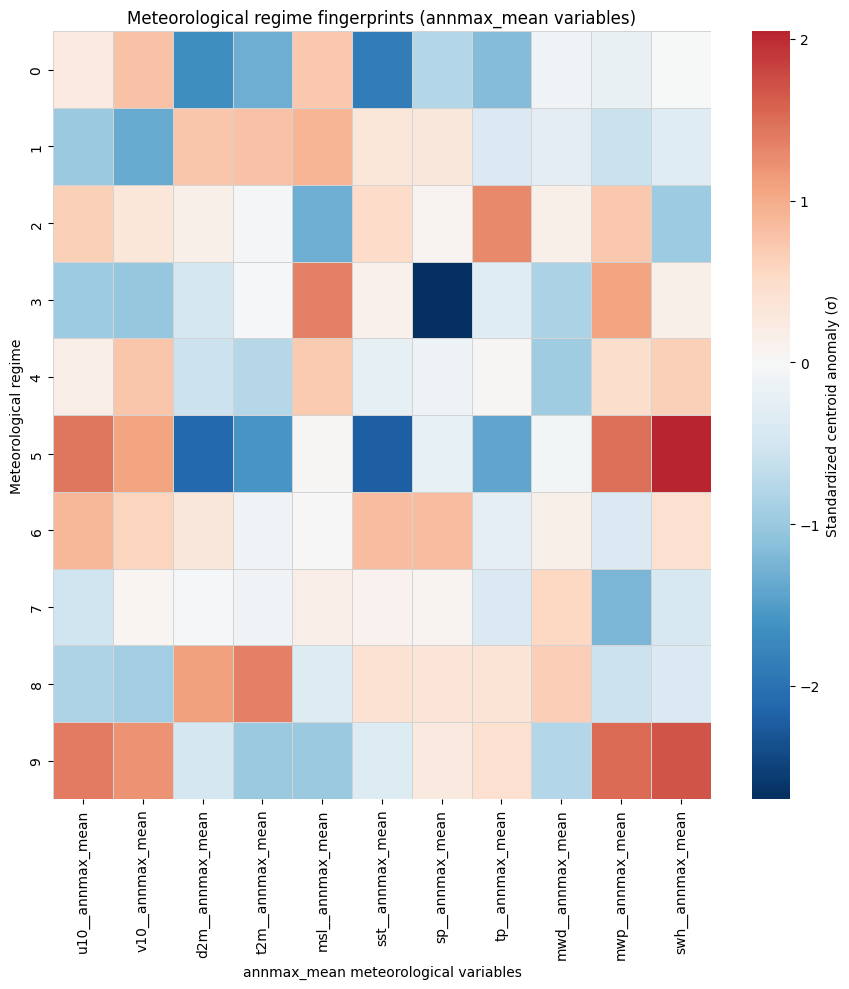

In [95]:
annmax_vars = [c for c in centroids_met_phys.columns if "annmax_mean" in c.lower()]
met_centroids_annmax = centroids_met_phys[annmax_vars].copy()
met_centroids_annmax.index.name = "met_regime"

annmax_std = centroids_met_std[annmax_vars]

# Optional: remove very weak dimensions
annmax_std = annmax_std.loc[:, annmax_std.abs().max(axis=0) > 0.5]

plt.figure(figsize=(0.45*annmax_std.shape[1] + 4,
                    0.7*annmax_std.shape[0] + 3))

sns.heatmap(
    annmax_std,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Standardized centroid anomaly (σ)"}
)

plt.xlabel("annmax_mean meteorological variables")
plt.ylabel("Meteorological regime")
plt.title("Meteorological regime fingerprints (annmax_mean variables)")
plt.tight_layout()
plt.show()


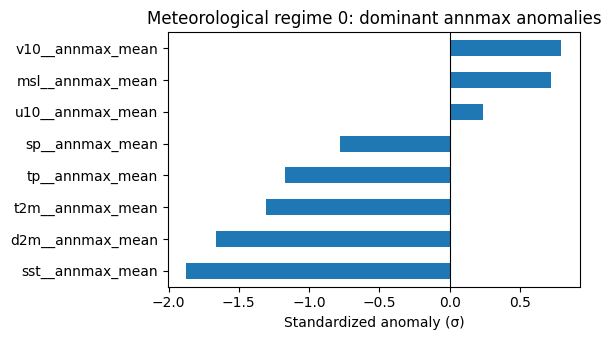

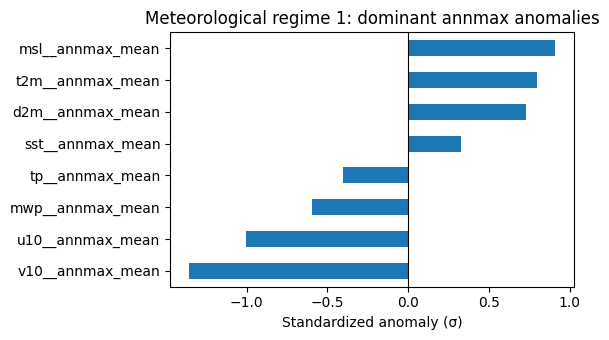

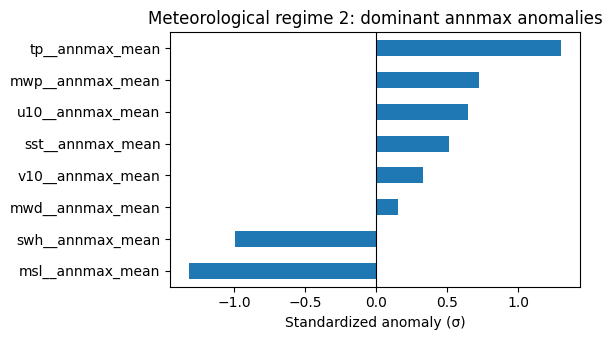

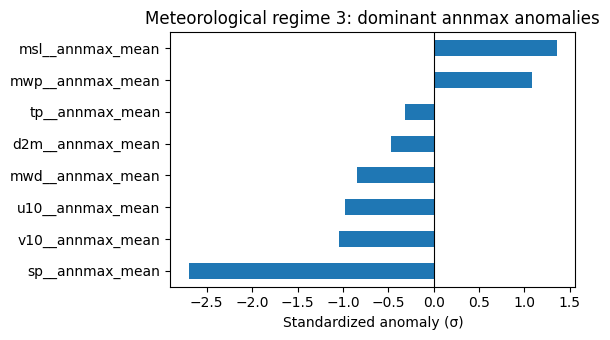

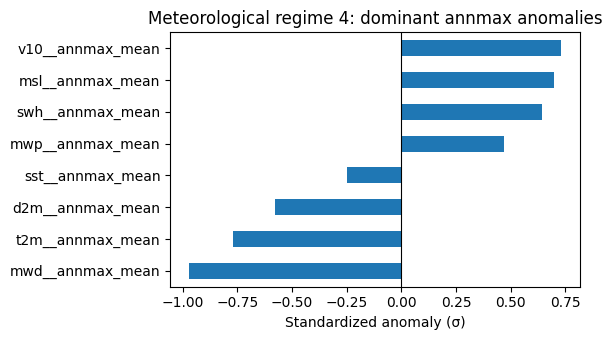

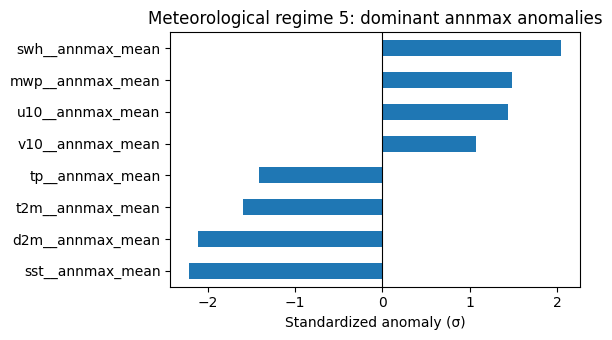

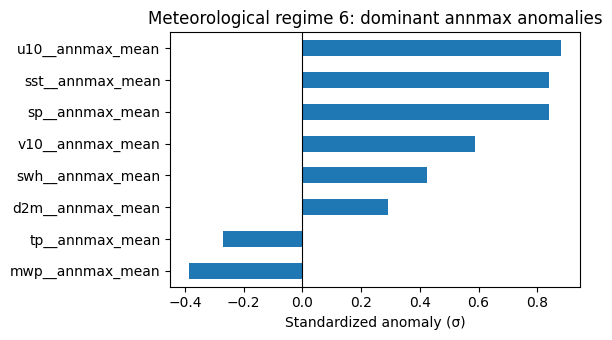

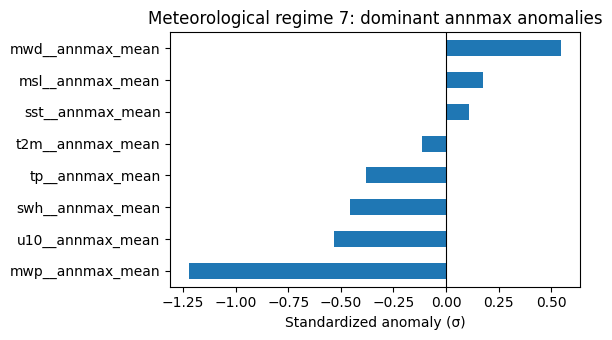

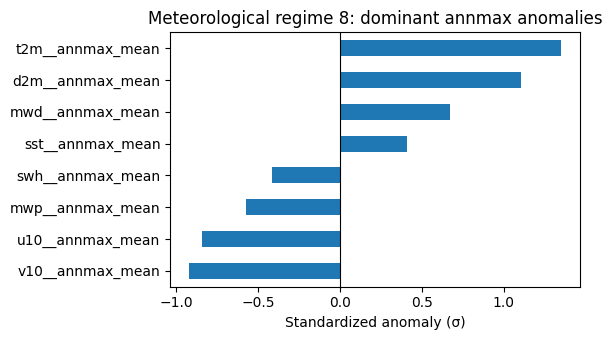

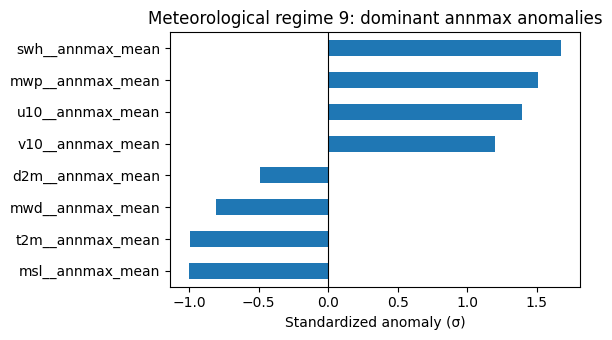

In [96]:
import numpy as np

TOP = 8

for mc in annmax_std.index:
    s = annmax_std.loc[mc].sort_values(key=lambda x: np.abs(x), ascending=False).head(TOP)

    plt.figure(figsize=(6,3.5))
    s.sort_values().plot(kind="barh")
    plt.axvline(0, color="k", lw=0.8)

    plt.title(f"Meteorological regime {mc}: dominant annmax anomalies")
    plt.xlabel("Standardized anomaly (σ)")
    plt.tight_layout()
    plt.show()


Dominant meteorological regimes: [1, 2, 8]


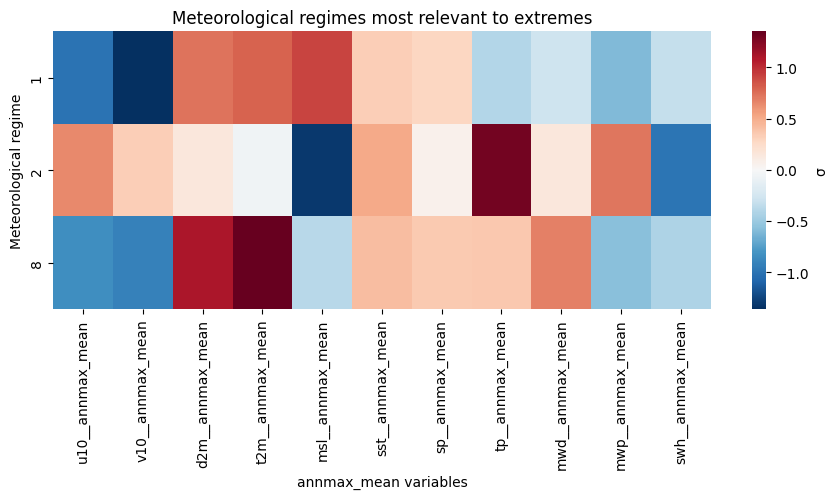

In [97]:
# meteorological regimes that dominate any extreme regime
dominant_mets = set(ct.idxmax(axis=1))
dominant_mets = sorted(dominant_mets)

print("Dominant meteorological regimes:", dominant_mets)

annmax_dom = annmax_std.loc[dominant_mets]

plt.figure(figsize=(0.45*annmax_dom.shape[1] + 4,
                    0.7*annmax_dom.shape[0] + 3))

sns.heatmap(annmax_dom, center=0, cmap="RdBu_r",
            cbar_kws={"label": "σ"})
plt.title("Meteorological regimes most relevant to extremes")
plt.xlabel("annmax_mean variables")
plt.ylabel("Meteorological regime")
plt.tight_layout()
plt.show()


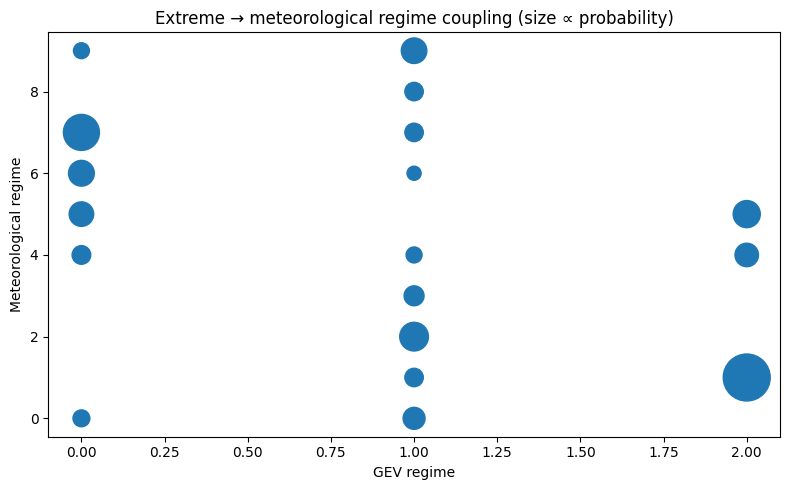

In [77]:
import matplotlib.pyplot as plt

flows = ct.stack().reset_index()
flows.columns = ["gev", "met", "p"]
flows = flows[flows["p"] > 0.05]  # keep only meaningful links

plt.figure(figsize=(8,5))
plt.scatter(flows["gev"], flows["met"], s=flows["p"]*2000)
plt.xlabel("GEV regime")
plt.ylabel("Meteorological regime")
plt.title("Extreme → meteorological regime coupling (size ∝ probability)")
plt.tight_layout()
plt.show()


In [67]:
ct2 = pd.crosstab(model_df["met_cluster"], model_df["cluster"], normalize="index")
print(ct2)


cluster             0         1         2
met_cluster                              
0            0.346154  0.653846  0.000000
1            0.076923  0.461538  0.461538
2            0.147059  0.852941  0.000000
3            0.210526  0.736842  0.052632
4            0.478261  0.391304  0.130435
5            0.791667  0.041667  0.166667
6            0.750000  0.250000  0.000000
7            0.759259  0.222222  0.018519
8            0.142857  0.857143  0.000000
9            0.258065  0.741935  0.000000


In [68]:
# For each meteorological cluster, list the strongest centroid anomalies (standardized)
centroids_met_std = pd.DataFrame(km_met.cluster_centers_, columns=X.columns)
spread = centroids_met_std.abs().max(axis=0)

# For each meteorological cluster, print top defining variables
TOP = 10
for mc in range(best_k_met):
    s = centroids_met_std.loc[mc].sort_values(key=lambda x: abs(x), ascending=False).head(TOP)
    print(f"\nMeteorological cluster {mc} top centroid components:")
    print(s)



Meteorological cluster 0 top centroid components:
sst__q95           -1.820579
sst__annmax_mean   -1.814936
sst__annmax_min    -1.781586
d2m__annmax_min    -1.682370
sst__annmax_max    -1.657649
sst__max           -1.657649
v10__annmean_max    1.656703
t2m__q95           -1.621361
d2m__annmax_mean   -1.616575
d2m__q95           -1.615778
Name: 0, dtype: float64

Meteorological cluster 1 top centroid components:
d2m__q05            -1.965132
d2m__annmean_min    -1.811776
t2m__annmean_min    -1.779794
msl__annmax_std      1.766056
sp__annmax_std       1.751424
t2m__q05            -1.721811
d2m__mean           -1.699212
d2m__annmean_mean   -1.698709
mwd__missing_frac    1.687301
mwp__missing_frac    1.687301
Name: 1, dtype: float64

Meteorological cluster 2 top centroid components:
t2m__q05             1.384273
d2m__annmean_min     1.366773
d2m__median          1.357846
t2m__annmean_min     1.331662
d2m__annmean_mean    1.323122
d2m__mean            1.322582
t2m__mean            1.276803

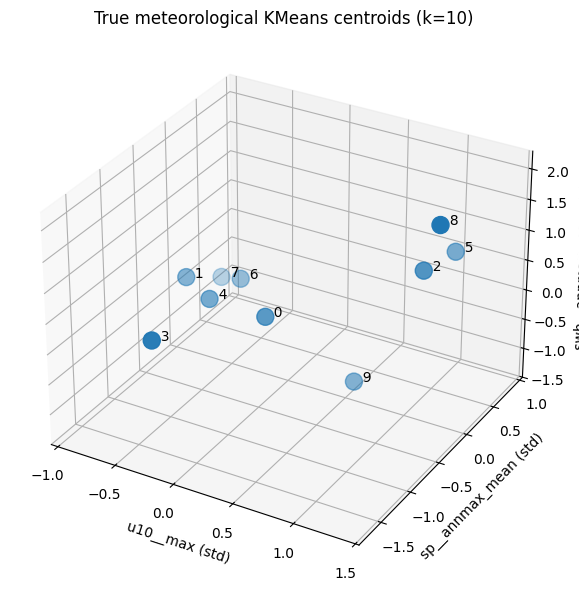

In [70]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.pyplot as plt

vars3 = ["u10__max", "sp__annmax_mean", "swh__annmax_mean"]  # use names that exist in X

C = centroids_met_std[vars3]  # true met centroids in standardized space

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(C[vars3[0]], C[vars3[1]], C[vars3[2]], s=150)

for mc in C.index:
    ax.text(C.loc[mc, vars3[0]], C.loc[mc, vars3[1]], C.loc[mc, vars3[2]], f"  {mc}", fontsize=10)

ax.set_xlabel(vars3[0] + " (std)")
ax.set_ylabel(vars3[1] + " (std)")
ax.set_zlabel(vars3[2] + " (std)")
ax.set_title(f"True meteorological KMeans centroids (k={best_k_met})")

plt.tight_layout()
plt.show()
